## ToDo

- Get a single simulation frame from a mixture of two molecules with several different atom types
- Calculate the energies and forces with the MACE-OMOL model
- Train to this and experiment with e.g. starting the parameters off in crazy places
- Contrast to training directly to condensed-phase properties -- do we better constrain the parameters?

## Some relevant literature

- Li et al. 2017 https://pubs.acs.org/doi/full/10.1021/acs.jctc.7b00521?casa_token=m6sk8hlrDu4AAAAA%3A3xx-_ZcGn07fcu6DHByQ1Sp3R4Q9QgtHUQ-06z7TLrrjSUREzgSouJq3t4bAwDCZxB0j4hHBe45J-xY
- Mezei 1991 https://pubs.acs.org/doi/pdf/10.1021/j100171a059?casa_token=MKxe9HP2QNcAAAAA:FWnsQgXW4n6WNvwVXMnsqAI_UMpU7zAOVak3CpWepkCNI_69AMy36t0HQIVRj4feL17BfZQ0FwL7lE0#page=8.34
- Izvekov, Parrinello et al. https://pubs.aip.org/aip/jcp/article-abstract/120/23/10896/981116/Effective-force-fields-for-condensed-phase-systems

Let's try and copy Li et al.

In [1]:
import smee
import smee.mm
import smee.converters
from openff.toolkit import Molecule, ForceField
from openff.interchange import Interchange
import tempfile
import openmm.unit
from pathlib import Path
import torch
from openmmml import MLPotential
import mdtraj
from tqdm import tqdm
import descent
import descent.utils.reporting
import descent.train
import matplotlib.pyplot as plt
import numpy as np

import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

SMILES = "[C:1]([H:3])([H:4])([H:5])[O:2][H:6]"
N_ATOMS_PER_MOL = Molecule.from_mapped_smiles(SMILES).n_atoms
N_MOL = 344
mol = Molecule.from_mapped_smiles(SMILES)
FF_NAME = "openff_unconstrained-2.2.1.offxml"
# FF_NAME = "../../input_ff/openff_unconstrained-2.2.0_zeroed.offxml"
MLP_NAME = "mace-off23-medium"
TRAJECTORY_PATH = Path("methanol_perturbed_rand0/trajectory.tr")
# TRAJECTORY_PATH = Path("methanol_sage221_unconstrained/trajectory.tr")
TRAINED_TRAJECTORY_PATH = Path(
    "methanol_perturbed_rand0_wider_final_ff/trajectory_trained.tr"
)
TEMPERATURE = 298.15 * openmm.unit.kelvin
PRESSURE = 1.0 * openmm.unit.atmosphere

mlp = MLPotential(MLP_NAME)


def perturb_tensor(tensor: torch.Tensor, frac: float = 0.2) -> torch.Tensor:
    """Multiply each value by a random factor in [1-frac, 1+frac]."""
    factor_low = 1.0 - frac
    factor_high = 1.0 + frac
    # Fix random seed for reproducibility
    torch.manual_seed(0)
    noise = torch.empty_like(tensor).uniform_(factor_low, factor_high)
    with torch.no_grad():
        tensor.mul_(noise)
    return tensor

### Run a simulation of methanol with Sage 2.2.1 unconstrained at 298 K/ 1 atm

Mainly stolen from https://github.com/SimonBoothroyd/smee/blob/aca69b9da4c67916c6e59ed2c435fffd4c49a2b6/examples/md-simulations.ipynb

In [51]:
# Need TensorSystem, TensorForceField, and Simulation config

# Get the TensorySystem
force_field = ForceField(FF_NAME)
interchange = Interchange.from_smirnoff(
    force_field,
    [Molecule.from_smiles(SMILES)],
)

tensor_ff, topologies = smee.converters.convert_interchange(interchange)
initial_vdw_params = tensor_ff.potentials_by_type["vdW"].parameters.detach().clone()
# Perturb the initial parameters
tensor_ff.potentials_by_type["vdW"].parameters = perturb_tensor(
    tensor_ff.potentials_by_type["vdW"].parameters, frac=0.2
)
print("Initial parameters:")
print(initial_vdw_params)
print("Perturbed parameters:")
print(tensor_ff.potentials_by_type["vdW"].parameters)


# move the force field to the GPU for faster processing of the simulation
# trajectories - the system and force field must be on the same device.
tensor_ff = tensor_ff.to("cuda")

vdw_potential = tensor_ff.potentials_by_type["vdW"]
vdw_potential.parameters.requires_grad = True

system = smee.TensorSystem([topologies[0]], [N_MOL], is_periodic=True)

# Create a trainable object
vdw_parameter_config = descent.train.ParameterConfig(
    cols=["epsilon", "sigma"],
    scales={"epsilon": 10.0, "sigma": 1.0},
    limits={"epsilon": (0.0, None), "sigma": (0.0, None)},
)

trainable = descent.train.Trainable(
    force_field=tensor_ff, parameters={"vdW": vdw_parameter_config}, attributes={}
)

# Get the Simulation config
beta = 1.0 / (openmm.unit.MOLAR_GAS_CONSTANT_R * TEMPERATURE)

# we can run an arbitrary number of equilibration simulations / minimizations.
# all generated data will be discarded, but the final coordinates will be used
# to initialize the production simulation
equilibrate_config = [
    smee.mm.MinimizationConfig(),
    # short NVT equilibration simulation
    smee.mm.SimulationConfig(
        temperature=TEMPERATURE,
        pressure=None,
        n_steps=50_000,
        timestep=1.0 * openmm.unit.femtosecond,
    ),
    # short NPT equilibration simulation
    smee.mm.SimulationConfig(
        temperature=TEMPERATURE,
        pressure=PRESSURE,
        n_steps=50_000,
        timestep=1.0 * openmm.unit.femtosecond,
    ),
]
# long NPT production simulation
production_config = smee.mm.SimulationConfig(
    temperature=TEMPERATURE,
    pressure=PRESSURE,
    n_steps=1_000_000,
    # n_steps=10_000,
    timestep=1.0 * openmm.unit.femtosecond,
)

Initial parameters:
tensor([[1.0884e-01, 3.3795e+00],
        [1.6409e-02, 2.5832e+00],
        [2.0947e-01, 2.9972e+00],
        [1.2326e-05, 5.3454e-01]], dtype=torch.float64)
Perturbed parameters:
tensor([[1.2930e-01, 3.6605e+00],
        [1.6143e-02, 3.0180e+00],
        [2.2163e-01, 3.3462e+00],
        [1.0741e-05, 5.0270e-01]], dtype=torch.float64)


/tmp/ipykernel_2895033/3133050503.py:7: AtomMappingWarning: Warning! Fully mapped SMILES pattern passed to `from_smiles`. The atom map is stored as a property in `Molecule._properties`, but these indices are NOT used to determine atom ordering. To use these indices for atom ordering, use `Molecule.from_mapped_smiles`.
  [Molecule.from_smiles(SMILES)],


In [3]:
def simulate(
    system: smee.TensorSystem,
    force_field: smee.TensorForceField,
    output_traj_path: Path,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Run a simulation and save the trajectory to the specified path."""
    # Make the output directory if it doesn't exist
    output_dir = output_traj_path.parent
    output_dir.mkdir(parents=True, exist_ok=True)

    # computing the ensemble averages is a two step process - we first need to run
    # an MD simulation using the force field making sure to store the coordinates,
    # box vectors and kinetic energies
    initial_coords, box_vectors = smee.mm.generate_system_coords(system, force_field)

    interval = 2000

    # save the simulation output every 2000th frame (2 ps) to a tensor_reporter and
    # a dcd reporter
    pdb_reporter_file = output_dir / "trajectory.pdb"
    pdb_reporter = openmm.app.PDBReporter(pdb_reporter_file.as_posix(), interval)

    with smee.mm.tensor_reporter(
        output_traj_path, interval, beta, PRESSURE
    ) as tensor_reporter:
        smee.mm.simulate(
            system,
            force_field,
            initial_coords,
            box_vectors,
            equilibrate_config,
            production_config,
            [tensor_reporter, pdb_reporter],
        )

    return initial_coords, box_vectors

In [4]:
# Run the simulation
if TRAJECTORY_PATH.exists():
    raise ValueError(f"Trajectory path {TRAJECTORY_PATH} already exists.")

initial_coords, initial_box_vectors = simulate(system, tensor_ff, TRAJECTORY_PATH)

In [4]:
# Extract all of the coords and box vectors
coords = []
box_vectors = []
SUBSAMPLE_FREQ = 20

with TRAJECTORY_PATH.open("rb") as f:
    for i, (coord, box_vector, _, kinetic) in tqdm(
        enumerate(smee.mm._reporters.unpack_frames(f))
    ):
        if i % SUBSAMPLE_FREQ != 0:
            continue

        # coords.append(coord.to("cuda"))
        # box_vectors.append(box_vector.to("cuda"))
        coords.append(coord)
        box_vectors.append(box_vector)

500it [00:00, 47882.37it/s]


In [5]:
print(f"Number of frames: {len(coords)}")

Number of frames: 25


## Create datasets with volume scaling

In [6]:
def compute_molecule_coms(coords: torch.Tensor, n_atoms_per_mol: int) -> torch.Tensor:
    """
    Compute center of mass for each molecule (assuming equal atomic masses).

    Args:
        coords: Coordinates with shape (n_atoms, 3) or (n_frames, n_atoms, 3)
        n_atoms_per_mol: Number of atoms per molecule

    Returns:
        Center of mass positions with shape (n_molecules, 3) or (n_frames, n_molecules, 3)
    """
    if coords.ndim == 2:
        # Single frame: (n_atoms, 3)
        n_atoms = coords.shape[0]
        n_molecules = n_atoms // n_atoms_per_mol

        # Reshape to (n_molecules, n_atoms_per_mol, 3) and take mean
        coords_reshaped = coords.reshape(n_molecules, n_atoms_per_mol, 3)
        coms = coords_reshaped.mean(dim=1)  # (n_molecules, 3)

    elif coords.ndim == 3:
        # Multiple frames: (n_frames, n_atoms, 3)
        n_frames, n_atoms = coords.shape[:2]
        n_molecules = n_atoms // n_atoms_per_mol

        # Reshape to (n_frames, n_molecules, n_atoms_per_mol, 3) and take mean
        coords_reshaped = coords.reshape(n_frames, n_molecules, n_atoms_per_mol, 3)
        coms = coords_reshaped.mean(dim=2)  # (n_frames, n_molecules, 3)
    else:
        raise ValueError(f"coords must be 2D or 3D, got shape {coords.shape}")

    return coms


def get_box_center(box_vectors: torch.Tensor) -> torch.Tensor:
    """
    Compute the center of the simulation box.

    Args:
        box_vectors: Box vectors with shape (3, 3) or (n_frames, 3, 3)

    Returns:
        Box center with shape (3,) or (n_frames, 3)
    """
    if box_vectors.ndim == 2:
        # Single box: (3, 3) - center is half the diagonal
        center = 0.5 * torch.diagonal(box_vectors)
    elif box_vectors.ndim == 3:
        # Multiple boxes: (n_frames, 3, 3)
        center = 0.5 * torch.diagonal(box_vectors, dim1=1, dim2=2)
    else:
        raise ValueError(f"box_vectors must be 2D or 3D, got shape {box_vectors.shape}")

    return center


def scale_molecule_positions(
    coords: torch.Tensor,
    box_vectors: torch.Tensor,
    n_atoms_per_mol: int,
    scale_factor: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Scale molecular positions rigidly around the box center.

    This function:
    1. Computes the center of mass (COM) for each molecule
    2. Expands/contracts the COMs around the box center by scale_factor
    3. Translates all atoms in each molecule to match the new COM positions
    4. Scales the box vectors by the same factor

    Args:
        coords: Atomic coordinates with shape (n_atoms, 3) or (n_frames, n_atoms, 3)
        box_vectors: Box vectors with shape (3, 3) or (n_frames, 3, 3)
        n_atoms_per_mol: Number of atoms per molecule
        scale_factor: Scaling factor (>1 expands, <1 contracts, 1.0 = no change)

    Returns:
        Tuple of (scaled_coords, scaled_box_vectors) with same shapes as inputs
    """
    # Handle single frame vs multiple frames
    single_frame = coords.ndim == 2

    if single_frame:
        # Add batch dimension for uniform processing
        coords = coords.unsqueeze(0)
        box_vectors = box_vectors.unsqueeze(0)

    n_frames, n_atoms = coords.shape[:2]
    n_molecules = n_atoms // n_atoms_per_mol

    # Compute molecular centers of mass
    coms = compute_molecule_coms(coords, n_atoms_per_mol)  # (n_frames, n_molecules, 3)

    # Get box centers
    box_centers = get_box_center(box_vectors)  # (n_frames, 3)

    # Compute displacement vectors from box center to each COM
    # box_centers: (n_frames, 3) -> (n_frames, 1, 3) for broadcasting
    displacements = coms - box_centers.unsqueeze(1)  # (n_frames, n_molecules, 3)

    # Scale displacements
    scaled_displacements = displacements * scale_factor

    # Compute new COMs
    new_coms = (
        box_centers.unsqueeze(1) + scaled_displacements
    )  # (n_frames, n_molecules, 3)

    # Compute translation vector for each molecule
    translations = new_coms - coms  # (n_frames, n_molecules, 3)

    # Apply translations to all atoms in each molecule
    # Reshape to apply per-molecule translations
    coords_reshaped = coords.reshape(n_frames, n_molecules, n_atoms_per_mol, 3)

    # Broadcast translations: (n_frames, n_molecules, 1, 3)
    translations_expanded = translations.unsqueeze(2)

    # Apply translation
    scaled_coords = coords_reshaped + translations_expanded

    # Reshape back to original shape
    scaled_coords = scaled_coords.reshape(n_frames, n_atoms, 3)

    # Scale box vectors
    scaled_box_vectors = box_vectors * scale_factor

    # Remove batch dimension if input was single frame
    if single_frame:
        scaled_coords = scaled_coords.squeeze(0)
        scaled_box_vectors = scaled_box_vectors.squeeze(0)

    return scaled_coords, scaled_box_vectors


def create_scaled_dataset(
    coords: torch.Tensor,
    box_vectors: torch.Tensor,
    n_atoms_per_mol: int,
    scale_factors: list[float],
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Create a dataset with multiple scaled versions of the input configurations.

    Args:
        coords: Coordinates with shape (n_frames, n_atoms, 3)
        box_vectors: Box vectors with shape (n_frames, 3, 3)
        n_atoms_per_mol: Number of atoms per molecule
        scale_factors: List of scaling factors to apply

    Returns:
        Tuple of (all_coords, all_box_vectors) where each has the original frames
        plus scaled versions. Output shapes:
        - coords: (n_frames * n_scales, n_atoms, 3)
        - box_vectors: (n_frames * n_scales, 3, 3)
    """
    all_coords = []
    all_box_vectors = []

    for scale in scale_factors:
        scaled_coords, scaled_box_vecs = scale_molecule_positions(
            coords, box_vectors, n_atoms_per_mol, scale
        )
        all_coords.append(scaled_coords)
        all_box_vectors.append(scaled_box_vecs)

    # Concatenate all scaled versions along frame dimension
    all_coords = torch.cat(all_coords, dim=0)
    all_box_vectors = torch.cat(all_box_vectors, dim=0)

    return all_coords, all_box_vectors


# Test the functions with a simple example
def test_scaling_functions():
    """Test the scaling functions with a simple case."""
    print("Testing scaling functions...")

    # Create simple test case: 2 molecules, 3 atoms each, 1 frame
    n_atoms_per_mol = 3
    n_molecules = 2

    # Simple coordinates: molecules at different positions
    coords_test = torch.tensor(
        [
            # Molecule 1
            [1.0, 1.0, 1.0],
            [1.5, 1.0, 1.0],
            [1.0, 1.5, 1.0],
            # Molecule 2
            [3.0, 3.0, 3.0],
            [3.5, 3.0, 3.0],
            [3.0, 3.5, 3.0],
        ]
    )

    # Box vectors (4 Å cubic box)
    box_vectors_test = torch.eye(3) * 4.0

    # Test COM computation
    coms = compute_molecule_coms(coords_test, n_atoms_per_mol)
    print(f"Molecular COMs: {coms}")

    # Test box center
    box_center = get_box_center(box_vectors_test)
    print(f"Box center: {box_center}")

    # Test scaling
    scale_factor = 1.1
    scaled_coords, scaled_box = scale_molecule_positions(
        coords_test, box_vectors_test, n_atoms_per_mol, scale_factor
    )

    print(f"\nOriginal box diagonal: {torch.diagonal(box_vectors_test)}")
    print(f"Scaled box diagonal: {torch.diagonal(scaled_box)}")
    print(f"Expected: {torch.diagonal(box_vectors_test) * scale_factor}")

    # Verify molecular geometries are preserved
    new_coms = compute_molecule_coms(scaled_coords, n_atoms_per_mol)
    print(f"\nOriginal COMs: {coms}")
    print(f"Scaled COMs: {new_coms}")

    print("\n✅ Test completed!")


# Run the test
test_scaling_functions()

Testing scaling functions...
Molecular COMs: tensor([[1.1667, 1.1667, 1.0000],
        [3.1667, 3.1667, 3.0000]])
Box center: tensor([2., 2., 2.])

Original box diagonal: tensor([4., 4., 4.])
Scaled box diagonal: tensor([4.4000, 4.4000, 4.4000])
Expected: tensor([4.4000, 4.4000, 4.4000])

Original COMs: tensor([[1.1667, 1.1667, 1.0000],
        [3.1667, 3.1667, 3.0000]])
Scaled COMs: tensor([[1.0833, 1.0833, 0.9000],
        [3.2833, 3.2833, 3.1000]])

✅ Test completed!


### Apply Scaling to Create Augmented Dataset

Now let's apply the scaling to our actual trajectory data to create configurations at different densities.

In [18]:
# Example: Create scaled versions of our trajectory data
# Stack coordinates and box vectors into tensors
coords_stacked = coords[0].unsqueeze(0)
box_vectors_stacked = box_vectors[0].unsqueeze(0)

print(
    f"Original data shape: coords {coords_stacked.shape}, box_vectors {box_vectors_stacked.shape}"
)

# Define scaling factors
# < 1.0 = compression (higher density)
# > 1.0 = expansion (lower density)
# 1.0 = original (reference)
# scale_factors = [0.95, 0.98, 1.0, 1.02, 1.05]
close_range = np.linspace(0.85, 1.0, 15)
long_range = np.linspace(1.0, 2, 10)
scale_factors = np.concatenate((close_range, long_range[1:]))

# Create augmented dataset
coords_augmented, box_vectors_augmented = create_scaled_dataset(
    coords_stacked,
    box_vectors_stacked,
    n_atoms_per_mol=mol.n_atoms,
    scale_factors=scale_factors,
)

print(
    f"Augmented data shape: coords {coords_augmented.shape}, box_vectors {box_vectors_augmented.shape}"
)
print(
    f"Total configurations: {len(coords_augmented)} (original: {len(coords_stacked)} × {len(scale_factors)} scales)"
)

# Show density changes
original_volume = torch.det(box_vectors_stacked[0]).item()
scaled_volumes = [
    torch.det(box_vectors_augmented[i * len(coords_stacked)]).item()
    for i in range(len(scale_factors))
]

print("\nVolume scaling (Å³):")
for scale, vol in zip(scale_factors, scaled_volumes):
    density_ratio = original_volume / vol
    print(f"  Scale {scale:.2f}: Volume = {vol:.2f} Å³ (density × {density_ratio:.3f})")

Original data shape: coords torch.Size([1, 2064, 3]), box_vectors torch.Size([1, 3, 3])
Augmented data shape: coords torch.Size([24, 2064, 3]), box_vectors torch.Size([24, 3, 3])
Total configurations: 24 (original: 1 × 24 scales)

Volume scaling (Å³):
  Scale 0.85: Volume = 19334.62 Å³ (density × 1.628)
  Scale 0.86: Volume = 20075.01 Å³ (density × 1.568)
  Scale 0.87: Volume = 20834.07 Å³ (density × 1.511)
  Scale 0.88: Volume = 21612.03 Å³ (density × 1.457)
  Scale 0.89: Volume = 22409.12 Å³ (density × 1.405)
  Scale 0.90: Volume = 23225.56 Å³ (density × 1.356)
  Scale 0.91: Volume = 24061.60 Å³ (density × 1.308)
  Scale 0.93: Volume = 24917.47 Å³ (density × 1.263)
  Scale 0.94: Volume = 25793.40 Å³ (density × 1.221)
  Scale 0.95: Volume = 26689.62 Å³ (density × 1.180)
  Scale 0.96: Volume = 27606.35 Å³ (density × 1.140)
  Scale 0.97: Volume = 28543.85 Å³ (density × 1.103)
  Scale 0.98: Volume = 29502.33 Å³ (density × 1.067)
  Scale 0.99: Volume = 30482.04 Å³ (density × 1.033)
  Scal

## Now get the energies and forces with MACE-OFF large

(Switch to the OMOL model eventually)

In [22]:
mlp = MLPotential(MLP_NAME)

omm_topology = smee.converters.convert_to_openmm_topology(system)
omm_topology.setPeriodicBoxVectors(
    box_vectors[0].detach().to("cpu").numpy() * openmm.unit.angstrom
)
omm_mlp_system = mlp.createSystem(omm_topology, removeCMMotion=False)
# GPU issues...
cpu_platform = openmm.Platform.getPlatformByName("CPU")

integrator = openmm.LangevinMiddleIntegrator(
    production_config.temperature,
    production_config.friction_coeff,
    production_config.timestep,
)
simulation_ml = openmm.app.Simulation(
    omm_topology, omm_mlp_system, integrator, platform=cpu_platform
)

Using MACE-OFF23 MODEL for MACECalculator with /home/campus.ncl.ac.uk/nfc78/.cache/mace/MACE-OFF23_medium.model


/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj-mace/lib/python3.12/site-packages/mace/calculators/foundations_models.py:250: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

In [23]:
# To debug, calculate the energies and forces with the original MM FF and check losses are 0
from smee.converters.openmm import convert_to_openmm_system
from openmm.app import Simulation

omm_sys = convert_to_openmm_system(tensor_ff, system)
integrator = openmm.LangevinMiddleIntegrator(
    production_config.temperature,
    production_config.friction_coeff,
    production_config.timestep,
)
omm_simulation = Simulation(omm_topology, omm_sys, integrator, platform=cpu_platform)
cpu_coords = [c.detach().to("cpu").numpy() for c in coords_augmented]
cpu_box_vectors = [bv.detach().to("cpu").numpy() for bv in box_vectors_augmented]

energies = []
forces = []

for coord, box_vector in tqdm(zip(cpu_coords, cpu_box_vectors), total=len(cpu_coords)):
    omm_simulation.context.setPositions(coord * openmm.unit.angstrom)
    omm_simulation.context.setPeriodicBoxVectors(*box_vector * openmm.unit.angstrom)
    state = omm_simulation.context.getState(getEnergy=True, getForces=True)
    energy = state.getPotentialEnergy().value_in_unit(openmm.unit.kilocalorie_per_mole)
    force = state.getForces(asNumpy=True).value_in_unit(
        openmm.unit.kilocalorie_per_mole / openmm.unit.angstrom
    )
    energies.append(energy)
    forces.append(force)
    # Free GPU memory
    torch.cuda.empty_cache()

100%|██████████| 24/24 [00:00<00:00, 421.55it/s]


In [24]:
IDX = 0
coords_smee = torch.tensor(coords_augmented[IDX], device="cpu").requires_grad_(True)
box_vectors_smee = torch.tensor(box_vectors_augmented[IDX], device="cpu")
system = system.to("cpu")
tensor_ff = tensor_ff.to("cpu")
smee_energy = smee.compute_energy(system, tensor_ff, coords_smee, box_vectors_smee)
smee_forces = -torch.autograd.grad(
    smee_energy, coords_smee, create_graph=True, retain_graph=True
)[0]
print(
    f"Energy comparison (kcal/mol): Smee {smee_energy.item():.4f} vs OpenMM {energies[IDX]:.4f}"
)
print(f"Force comparison (kcal/mol/nm):")
print(f"Smee forces:\n{smee_forces}")
print(f"OpenMM forces:\n{forces[IDX]}")

/tmp/ipykernel_2895033/599804692.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coords_smee = torch.tensor(coords_augmented[IDX], device="cpu").requires_grad_(True)
/tmp/ipykernel_2895033/599804692.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_vectors_smee = torch.tensor(box_vectors_augmented[IDX], device="cpu")
[W1010 20:53:50.613765385 LinearAlgebra.cpp:3063] Warning: at::frobenius_norm is deprecated and it is just left for JIT compatibility. It will be removed in a future PyTorch release. Please use `linalg.vector_norm(A, 2., dim, keepdim)` instead (function operator())


Energy comparison (kcal/mol): Smee 9439.9424 vs OpenMM 9439.9546
Force comparison (kcal/mol/nm):
Smee forces:
tensor([[ 28.0930, -67.8055,  15.1396],
        [-12.4504, -10.3934,  17.4967],
        [ 98.0563, -26.4865, -32.4347],
        ...,
        [-25.8361,  54.1313,  28.1165],
        [ 94.8959,   4.4474,  63.7084],
        [ -9.0934,  17.1256, -15.2685]], grad_fn=<NegBackward0>)
OpenMM forces:
[[ 28.8456126  -64.43262023  15.65335245]
 [-11.79228701  -9.83161111  17.19865255]
 [ 97.44022347 -25.73452295 -32.02335309]
 ...
 [-26.23010258  54.13786878  28.15901404]
 [ 61.25883558  25.49685621  51.22056994]
 [ -3.01519824  12.77327301 -17.97466192]]


/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj-mace/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: pme::pme_reciprocal: an autograd kernel was not registered to the Autograd key(s) but we are trying to backprop through it. This may lead to silently incorrect behavior. This behavior is deprecated and will be removed in a future version of PyTorch. If your operator is differentiable, please ensure you have registered an autograd kernel to the correct Autograd key (e.g. DispatchKey::Autograd, DispatchKey::CompositeImplicitAutograd). If your operator is not differentiable, or to squash this warning and use the previous behavior, please register torch::CppFunction::makeFallthrough() to DispatchKey::Autograd. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1733624414920/work/torch/csrc/autograd/autograd_not_implemented_fallback.cpp:62.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward 

In [25]:
# For the scaled configs

cpu_coords = [c.detach().to("cpu").numpy() for c in coords_augmented]
cpu_box_vectors = [bv.detach().to("cpu").numpy() for bv in box_vectors_augmented]

energies = []
forces = []

for coord, box_vector in tqdm(zip(cpu_coords, cpu_box_vectors), total=len(cpu_coords)):
    simulation_ml.context.setPositions(coord * openmm.unit.angstrom)
    simulation_ml.context.setPeriodicBoxVectors(*box_vector * openmm.unit.angstrom)
    state = simulation_ml.context.getState(getEnergy=True, getForces=True)
    energy = state.getPotentialEnergy().value_in_unit(openmm.unit.kilocalorie_per_mole)
    force = state.getForces(asNumpy=True).value_in_unit(
        openmm.unit.kilocalorie_per_mole / openmm.unit.angstrom
    )
    energies.append(energy)
    forces.append(force)
    # Free GPU memory
    torch.cuda.empty_cache()

100%|██████████| 24/24 [03:28<00:00,  8.70s/it]


In [26]:
energies_and_forces = {
    "energies": np.array(energies),
    "forces": np.array(forces),
}

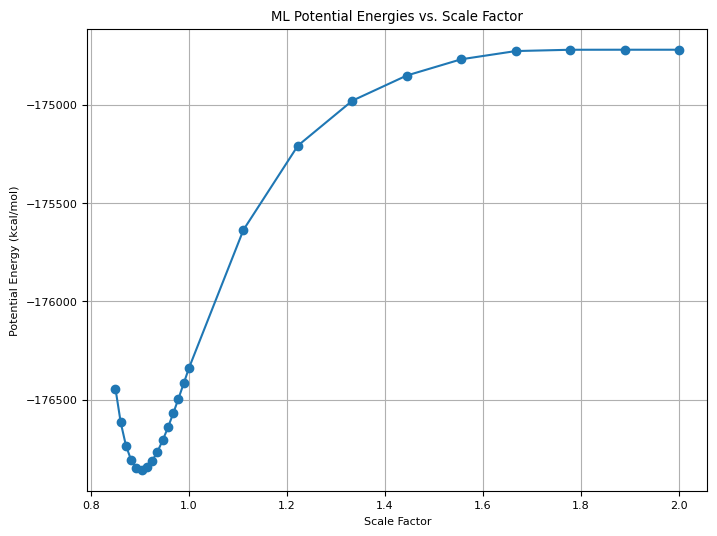

In [27]:
# Plot the energies of the scaled configurations
plt.figure(figsize=(8, 6))
plt.plot(scale_factors, energies, marker="o")
plt.title("ML Potential Energies vs. Scale Factor")
plt.xlabel("Scale Factor")
plt.ylabel("Potential Energy (kcal/mol)")
plt.grid(True)

## Modified from Descent...

In [28]:
"""Train against relative energies and forces."""

import typing

import datasets
import datasets.table
import pyarrow
import smee
import smee.utils
import torch

DATA_SCHEMA = pyarrow.schema(
    [
        ("smiles", pyarrow.string()),
        ("coords", pyarrow.list_(pyarrow.float64())),
        ("box_vectors", pyarrow.list_(pyarrow.float64())),
        ("energy", pyarrow.list_(pyarrow.float64())),
        ("forces", pyarrow.list_(pyarrow.float64())),
    ]
)


class Entry(typing.TypedDict):
    """Represents a set of reference energies and forces."""

    smiles: str
    """The indexed SMILES description of the molecule the energies and forces were
    computed for."""

    coords: torch.Tensor
    """The coordinates [Å] the energies and forces were evaluated at with
    ``shape=(n_confs, n_particles, 3)``."""

    box_vectors: torch.Tensor
    """The box vectors [Å] the energies and forces were evaluated at with
    ``shape=(n_confs, 3, 3)``."""

    energy: torch.Tensor
    """The reference energies [kcal/mol] with ``shape=(n_confs,)``."""
    forces: torch.Tensor
    """The reference forces [kcal/mol/Å] with ``shape=(n_confs, n_particles, 3)``."""


def create_dataset(entries: list[Entry]) -> datasets.Dataset:
    """Create a dataset from a list of existing entries.

    Args:
        entries: The entries to create the dataset from.

    Returns:
        The created dataset.
    """

    table = pyarrow.Table.from_pylist(
        [
            {
                "smiles": entry["smiles"],
                "coords": entry["coords"].clone().detach().flatten().tolist(),
                "box_vectors": entry["box_vectors"].clone().detach().flatten().tolist(),
                "energy": entry["energy"].clone().detach().flatten().tolist(),
                "forces": entry["forces"].clone().detach().flatten().tolist(),
            }
            for entry in entries
        ],
        schema=DATA_SCHEMA,
    )
    # TODO: validate rows
    dataset = datasets.Dataset(datasets.table.InMemoryTable(table))
    dataset.set_format("torch")

    return dataset


def extract_smiles(dataset: datasets.Dataset) -> list[str]:
    """Return a list of unique SMILES strings in the dataset.

    Args:
        dataset: The dataset to extract the SMILES strings from.

    Returns:
        The list of unique SMILES strings.
    """
    return sorted({*dataset.unique("smiles")})


def predict(
    dataset: datasets.Dataset,
    force_field: smee.TensorForceField,
    topologies: dict[str, smee.TensorTopology],
    reference: typing.Literal["mean", "min", "none"] = "none",
    normalize: bool = True,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Predict the relative energies [kcal/mol] and forces [kcal/mol/Å] of a dataset.

    Args:
        dataset: The dataset to predict the energies and forces of.
        force_field: The force field to use to predict the energies and forces.
        topologies: The topologies of the molecules in the dataset. Each key should be
            a fully indexed SMILES string.
        reference: The reference energy to compute the relative energies with respect
            to. This should be either the "mean" energy of all conformers, or the
            energy of the conformer with the lowest reference energy ("min").
        normalize: Whether to scale the relative energies by ``1/sqrt(n_confs_i)``
            and the forces by ``1/sqrt(n_confs_i * n_atoms_per_conf_i * 3)`` This
            is useful when wanting to compute the MSE per entry.

    Returns:
        The predicted and reference relative energies [kcal/mol] with
        ``shape=(n_confs,)``, and predicted and reference forces [kcal/mol/Å] with
        ``shape=(n_confs * n_atoms_per_conf, 3)``.
    """
    energy_ref_all, energy_pred_all = [], []
    forces_ref_all, forces_pred_all = [], []

    for entry in dataset:
        smiles = entry["smiles"]

        energy_ref = entry["energy"]
        forces_ref = entry["forces"].reshape(len(energy_ref), -1, 3)

        coords_flat = smee.utils.tensor_like(
            entry["coords"], force_field.potentials[0].parameters
        )

        coords = (
            (coords_flat.reshape(len(energy_ref), -1, 3)).detach().requires_grad_(True)
        )

        box_vectors_flat = smee.utils.tensor_like(
            entry["box_vectors"], force_field.potentials[0].parameters
        )
        box_vectors = (
            (box_vectors_flat.reshape(len(energy_ref), 3, 3))
            .detach()
            .requires_grad_(False)
        )

        topology = topologies[smiles]

        energy_pred = torch.zeros_like(energy_ref)
        for i, (coord, box_vector) in tqdm(
            enumerate(zip(coords, box_vectors)), total=len(coords)
        ):
            energy_pred[i] = smee.compute_energy(
                topology, force_field, coord, box_vector
            )
        # energy_pred = smee.compute_energy(topology, force_field, coords)
        forces_pred = -torch.autograd.grad(
            energy_pred.sum(),
            coords,
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )[0]

        if reference.lower() == "mean":
            energy_ref_0 = energy_ref.mean()
            energy_pred_0 = energy_pred.mean()
        elif reference.lower() == "min":
            min_idx = energy_ref.argmin()

            energy_ref_0 = energy_ref[min_idx]
            energy_pred_0 = energy_pred[min_idx]
        elif reference.lower() == "none":
            energy_ref_0 = 0
            energy_pred_0 = 0
        else:
            raise NotImplementedError(f"invalid reference energy {reference}")

        scale_energy, scale_forces = 1.0, 1.0

        if normalize:
            scale_energy = 1.0 / torch.sqrt(torch.tensor(energy_pred.numel()))
            scale_forces = 1.0 / torch.sqrt(torch.tensor(forces_pred.numel()))

        energy_ref_all.append(scale_energy * (energy_ref - energy_ref_0))
        forces_ref_all.append(scale_forces * forces_ref.reshape(-1, 3))

        energy_pred_all.append(scale_energy * (energy_pred - energy_pred_0))
        forces_pred_all.append(scale_forces * forces_pred.reshape(-1, 3))

    energy_pred_all = torch.cat(energy_pred_all)
    forces_pred_all = torch.cat(forces_pred_all)

    energy_ref_all = torch.cat(energy_ref_all)
    energy_ref_all = smee.utils.tensor_like(energy_ref_all, energy_pred_all)

    forces_ref_all = torch.cat(forces_ref_all)
    forces_ref_all = smee.utils.tensor_like(forces_ref_all, forces_pred_all)

    return (
        energy_ref_all,
        energy_pred_all,
        forces_ref_all,
        forces_pred_all,
    )

## Train the LJ parameters to match the forces from MACE

In [52]:
LR = 0.01
N_EPOCHS = 100
force_losses = []
energy_losses = []
energy_pred_all = []
forces_pred_all = []
DEVICE = "cpu"

# Move everything to the right device
coords = [c.detach().requires_grad_(True).to(DEVICE) for c in coords_augmented]
box_vectors = [b.to(DEVICE) for b in box_vectors_augmented]
energies = torch.tensor(energies_and_forces["energies"]).to(DEVICE)
forces = torch.tensor(energies_and_forces["forces"]).to(DEVICE)
tensor_ff = tensor_ff.to(DEVICE)
system = system.to(DEVICE)
trainable = descent.train.Trainable(
    force_field=tensor_ff, parameters={"vdW": vdw_parameter_config}, attributes={}
)
x = trainable.to_values()

# Create the dataset again on the right device
entry = Entry(
    smiles=SMILES,
    coords=torch.stack(coords).to(DEVICE),
    box_vectors=torch.stack(box_vectors).to(DEVICE),
    energy=torch.tensor(energies_and_forces["energies"]).to(DEVICE),
    forces=torch.tensor(energies_and_forces["forces"]).to(DEVICE),
)

dataset = create_dataset([entry])

In [29]:
LR = 0.01
N_EPOCHS = 100
force_losses = []
energy_losses = []
energy_pred_all = []
forces_pred_all = []
DEVICE = "cpu"

# Move everything to the right device
coords = [c.detach().requires_grad_(True).to(DEVICE) for c in coords_augmented]
box_vectors = [b.to(DEVICE) for b in box_vectors_augmented]
energies = torch.tensor(energies_and_forces["energies"]).to(DEVICE)
forces = torch.tensor(energies_and_forces["forces"]).to(DEVICE)
tensor_ff = tensor_ff.to(DEVICE)
system = system.to(DEVICE)
trainable = descent.train.Trainable(
    force_field=tensor_ff, parameters={"vdW": vdw_parameter_config}, attributes={}
)
x = trainable.to_values()

# Create the dataset again on the right device
entry = Entry(
    smiles=SMILES,
    coords=torch.stack(coords).to(DEVICE),
    box_vectors=torch.stack(box_vectors).to(DEVICE),
    energy=torch.tensor(energies_and_forces["energies"]).to(DEVICE),
    forces=torch.tensor(energies_and_forces["forces"]).to(DEVICE),
)

dataset = create_dataset([entry])

# Use only the forces for the loss

optimiser = torch.optim.Adam([x], lr=LR, amsgrad=True)
for epoch in range(N_EPOCHS):
    optimiser.zero_grad()

    energy_ref, energy_pred, forces_ref, forces_pred = predict(
        dataset,
        trainable.to_force_field(x).to(DEVICE),
        {SMILES: system},
        "min",
        normalize=False,
    )

    # Convert to differences in forces or energies between each configuration
    energy_0_idx = energy_ref.argmin()
    energy_ref_diffs = energy_ref - energy_ref[energy_0_idx]
    energy_pred_diffs = energy_pred - energy_pred[energy_0_idx]
    forces_ref_diffs = forces_ref - forces_ref[energy_0_idx]
    forces_pred_diffs = forces_pred - forces_pred[energy_0_idx]

    loss_energy = torch.sqrt(torch.mean((energy_pred_diffs - energy_ref_diffs) ** 2))
    loss_forces = torch.sqrt(torch.mean((forces_pred_diffs - forces_ref_diffs) ** 2))

    (grad_energy,) = torch.autograd.grad(
        loss_energy, x, create_graph=False, retain_graph=True
    )
    (grad_force,) = torch.autograd.grad(
        loss_forces, x, create_graph=False, retain_graph=True
    )
    x.grad = grad_energy + grad_force

    # loss_energy = torch.sqrt(torch.mean((energy_pred - energy_ref)**2))
    # loss_forces = torch.sqrt(torch.mean((forces_pred - forces_ref)**2))

    # (grad, ) = torch.autograd.grad(loss_forces, x, create_graph=False)
    # x.grad = grad

    # pred_energies, pred_forces = get_pred_energies_and_forces(system, trainable.to_force_field(x).to(DEVICE), coords, box_vectors)
    # loss_energy, loss_forces = get_loss(pred_energies, pred_forces, energies, forces, x)

    # (grad,) = torch.autograd.grad(loss_forces, x, create_graph=False)
    # x.grad = grad
    # Move losses to CPU and save as np array
    energy_pred_all.append(energy_pred.detach().cpu().to(torch.float32).numpy())
    forces_pred_all.append(forces_pred.detach().cpu().to(torch.float32).numpy())
    energy_losses.append(loss_energy.detach().cpu().to(torch.float32).numpy())
    force_losses.append(loss_forces.detach().cpu().to(torch.float32).numpy())
    print(f"Epoch {epoch}: loss_energy = {loss_energy}, loss_forces = {loss_forces}")
    print(x)
    print(x.grad)
    optimiser.step()
    # x = trainable.clamp(x).requires_grad_(True)
    torch.cuda.empty_cache()

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:00<00:00, 28.91it/s]


Epoch 0: loss_energy = 2535.669921875, loss_forces = 23.491903177772702
tensor([1.2930e+00, 3.6605e+00, 1.6143e-01, 3.0180e+00, 2.2163e+00, 3.3462e+00,
        1.0741e-04, 5.0270e-01], dtype=torch.float64, requires_grad=True)
tensor([5.1356e+01, 1.3851e+03, 6.3080e+03, 5.0996e+03, 6.5164e+02, 7.0548e+03,
        5.3428e+03, 6.2245e+00], dtype=torch.float64)


100%|██████████| 24/24 [00:00<00:00, 31.90it/s]


Epoch 1: loss_energy = 2335.59130859375, loss_forces = 22.843174787941653
tensor([ 1.2830,  3.6505,  0.1514,  3.0080,  2.2063,  3.3362, -0.0099,  0.4927],
       dtype=torch.float64, requires_grad=True)
tensor([  39.6697, 1297.9209, 6063.7083, 4654.6582,  616.1243, 6708.6925,
           0.0000,    0.0000], dtype=torch.float64)


...

Epoch 97: loss_energy = 40.65513229370117, loss_forces = 18.354454336918888
tensor([ 2.0982,  3.6022, -0.0979,  2.8100,  2.0916,  3.0114, -0.0597,  0.4429],
       dtype=torch.float64, requires_grad=True)
tensor([-60.8965, -11.9304,   0.0000,   0.0000, -28.6254, 197.2477,   0.0000,
          0.0000], dtype=torch.float64)


100%|██████████| 24/24 [00:00<00:00, 30.47it/s]


Epoch 98: loss_energy = 39.92656326293945, loss_forces = 18.354200079350562
tensor([ 2.1065,  3.6036, -0.0979,  2.8100,  2.0939,  3.0105, -0.0597,  0.4429],
       dtype=torch.float64, requires_grad=True)
tensor([-55.1453, -18.1025,   0.0000,   0.0000, -27.8024, 155.9179,   0.0000,
          0.0000], dtype=torch.float64)


100%|██████████| 24/24 [00:00<00:00, 30.87it/s]


Epoch 99: loss_energy = 39.2984733581543, loss_forces = 18.353941719484208
tensor([ 2.1144,  3.6049, -0.0979,  2.8100,  2.0961,  3.0096, -0.0597,  0.4429],
       dtype=torch.float64, requires_grad=True)
tensor([-49.2651, -24.8245,   0.0000,   0.0000, -26.9397, 113.4483,   0.0000,
          0.0000], dtype=torch.float64)


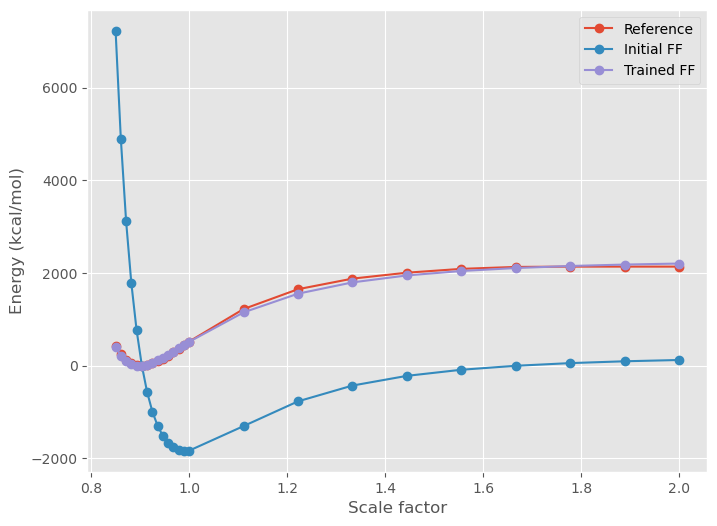

In [30]:
# Plot the initial energies and final trained energies against the scaling
plt.style.use("ggplot")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(scale_factors, energy_ref.detach().cpu().numpy(), label="Reference", marker="o")
ax.plot(scale_factors, energy_pred_all[0], label="Initial FF", marker="o")
ax.plot(scale_factors, energy_pred_all[-1], label="Trained FF", marker="o")
ax.set_xlabel("Scale factor")
ax.set_ylabel("Energy (kcal/mol)")
ax.legend()

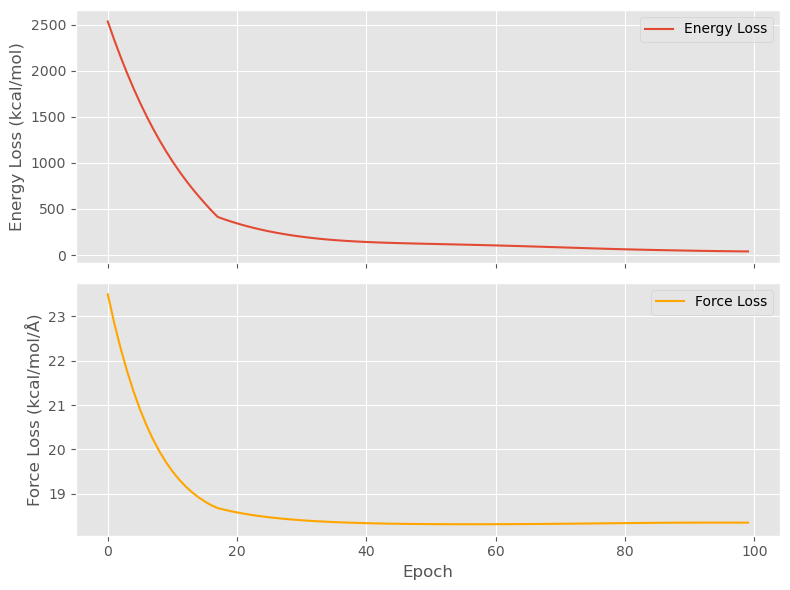

In [31]:
# Plot the losses
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(energy_losses, label="Energy Loss")
axs[0].set_ylabel("Energy Loss (kcal/mol)")
# axs[0].set_yscale("log")
axs[0].legend()
axs[1].plot(force_losses, label="Force Loss", color="orange")
axs[1].set_ylabel("Force Loss (kcal/mol/Å)")
# axs[1].set_yscale("log")
axs[1].set_xlabel("Epoch")
axs[1].legend()
plt.tight_layout()

In [32]:
print("Initial parameters:")
print(88 * "#")
descent.utils.reporting.print_potential_summary(
    trainable.to_force_field(trainable.to_values()).potentials_by_type["vdW"]
)
print("Final parameters:")
print(88 * "#")
descent.utils.reporting.print_potential_summary(
    trainable.to_force_field(x).potentials_by_type["vdW"]
)

Initial parameters:
########################################################################################
========================================= vdW ==========================================
fn=4*epsilon*((sigma/r)**12-(sigma/r)**6)

attributes=

scale_12 scale_13 scale_14 scale_15 cutoff [Å] switch_width [Å]
 0.0000   0.0000   0.5000   1.0000     9.0000           1.0000 

parameters=

                                  ID epsilon [kcal/mol] sigma [Å]
                            [#6X4:1]             0.1293    3.6605
[#1:1]-[#6X4]-[#7,#8,#9,#16,#17,#35]             0.0161    3.0180
                        [#8X2H1+0:1]             0.2216    3.3462
                         [#1:1]-[#8]             0.0000    0.5027
Final parameters:
########################################################################################
========================================= vdW ==========================================
fn=4*epsilon*((sigma/r)**12-(sigma/r)**6)

attributes=

scale_12 scale_13 scal

## Calculate the densities and enthalpies

In [53]:
import descent.targets.thermo

density_pure = {
    "type": "density",
    "smiles_a": SMILES,
    "x_a": 1.0,
    "smiles_b": None,
    "x_b": None,
    "temperature": 300.0,
    "pressure": 1.0,
    "value": 0.79,
    "std": 0.001,
    "units": "g/mL",
    "source": None,
}

hvap = {
    "type": "hvap",
    "smiles_a": SMILES,
    "x_a": 1.0,
    "smiles_b": None,
    "x_b": None,
    "temperature": 300.0,
    "pressure": 1.0,
    "value": 38.30,
    "std": 0.001,
    "units": "kcal/mol",
    "source": None,
}

dataset = descent.targets.thermo.create_dataset(density_pure, hvap)
results = descent.targets.thermo.predict(
    dataset,
    trainable.to_force_field(x).to(DEVICE),
    {SMILES: topologies[0]},
    output_dir=Path("./predictions2"),
    cached_dir=Path("./cache2"),
    verbose=True,
)
results

(tensor([ 0.7900, 38.3000]),
 tensor([0.0010, 0.0010]),
 tensor([0.5835, 6.2508], grad_fn=<StackBackward0>),
 tensor([0.0098, 1.5363]))

In [ ]:
import descent.targets.thermo

density_pure = {
    "type": "density",
    "smiles_a": SMILES,
    "x_a": 1.0,
    "smiles_b": None,
    "x_b": None,
    "temperature": 300.0,
    "pressure": 1.0,
    "value": 0.79,
    "std": 0.001,
    "units": "g/mL",
    "source": None,
}

hvap = {
    "type": "hvap",
    "smiles_a": SMILES,
    "x_a": 1.0,
    "smiles_b": None,
    "x_b": None,
    "temperature": 300.0,
    "pressure": 1.0,
    "value": 38.30,
    "std": 0.001,
    "units": "kcal/mol",
    "source": None,
}

dataset = descent.targets.thermo.create_dataset(density_pure, hvap)
results = descent.targets.thermo.predict(
    dataset,
    trainable.to_force_field(x).to(DEVICE),
    {SMILES: topologies[0]},
    output_dir=Path("./predictions2"),
    cached_dir=Path("./cache2"),
    verbose=True,
)
results

In [50]:
results

(tensor([ 0.7900, 38.3000]),
 tensor([0.0010, 0.0010]),
 tensor([0.7652, 8.5747], grad_fn=<StackBackward0>),
 tensor([0.0141, 1.4542]))

In [ ]:
import descent.targets.thermo

density_pure = {
    "type": "density",
    "smiles_a": SMILES,
    "x_a": 1.0,
    "smiles_b": None,
    "x_b": None,
    "temperature": 300.0,
    "pressure": 1.0,
    "value": 0.79,
    "std": 0.001,
    "units": "g/mL",
    "source": None,
}

hvap = {
    "type": "hvap",
    "smiles_a": SMILES,
    "x_a": 1.0,
    "smiles_b": None,
    "x_b": None,
    "temperature": 300.0,
    "pressure": 1.0,
    "value": 38.30,
    "std": 0.001,
    "units": "kcal/mol",
    "source": None,
}

dataset = descent.targets.thermo.create_dataset(density_pure, hvap)
results = descent.targets.thermo.predict(
    dataset,
    trainable.to_force_field(x).to(DEVICE),
    {SMILES: topologies[0]},
    output_dir=Path("./predictions"),
    cached_dir=Path("./cache"),
    verbose=True,
)

In [44]:
results

(tensor([ 0.7900, 38.3000]),
 tensor([0.0010, 0.0010]),
 tensor([0.8379, 8.4262], grad_fn=<StackBackward0>),
 tensor([0.0128, 1.5104]))

## Run a simulation with the trained force field

In [103]:
trainable.to_force_field(trainable.to_values()).potentials_by_type["vdW"].parameters

tensor([[1.2702e-01, 2.8346e+00],
        [1.7779e-02, 2.6248e+00],
        [2.4410e-01, 3.0280e+00],
        [1.0454e-05, 4.8471e-01]], dtype=torch.float64,
       grad_fn=<ViewBackward0>)

In [33]:
trained_tensor_ff = trainable.to_force_field(x)
if TRAINED_TRAJECTORY_PATH.exists():
    raise ValueError(f"Trajectory path {TRAINED_TRAJECTORY_PATH} already exists.")

initial_coords, initial_box_vectors = simulate(
    system, trained_tensor_ff, TRAINED_TRAJECTORY_PATH
)

##

## Get the predicted condensed phase properties with each force field

In [34]:
ffs = {"Initial": tensor_ff, "Trained": trained_tensor_ff.to("cpu")}
trajs = {"Initial": TRAJECTORY_PATH, "Trained": TRAINED_TRAJECTORY_PATH}
avgs_and_stds = {}

for name, ff in ffs.items():
    avgs, stds = smee.mm.compute_ensemble_averages(
        system, ff, trajs[name], TEMPERATURE, PRESSURE
    )
    avgs_and_stds[name] = {"avgs": avgs, "stds": stds}

In [35]:
# Print a nice summary table of all
for name, data in avgs_and_stds.items():
    print(f"{name} averages:")
    for prop, value in data["avgs"].items():
        std = data["stds"][prop]
        print(f"  {prop}: {value:.3g} ± {std:.3g}")

Initial averages:
  potential_energy: 840 ± 42.3
  potential_energy^2: 7.08e+05 ± 7.09e+04
  volume: 3.14e+04 ± 438
  volume^2: 9.83e+08 ± 2.75e+07
  density: 0.584 ± 0.00814
  enthalpy: 2.68e+03 ± 53.4
  enthalpy^2: 7.16e+06 ± 2.85e+05
  enthalpy_volume: 8.39e+07 ± 2.4e+06
Trained averages:
  potential_energy: -205 ± 41.4
  potential_energy^2: 4.37e+04 ± 1.69e+04
  volume: 2.18e+04 ± 318
  volume^2: 4.75e+08 ± 1.39e+07
  density: 0.84 ± 0.0123
  enthalpy: 1.63e+03 ± 58.1
  enthalpy^2: 2.65e+06 ± 1.89e+05
  enthalpy_volume: 3.55e+07 ± 1.52e+06
